<a href="https://colab.research.google.com/github/M-AdityoRahman/PCVK_Ganjil_2025/blob/main/week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

**Konvolusi tanpa Library**

In [3]:
def convolution(image, kernel):
    # Pastikan gambar grayscale
    h, w = image.shape
    kh, kw = kernel.shape
    pad = kh // 2

    # Padding (zero-padding)
    padded = np.pad(image, pad, mode='constant', constant_values=0)

    # Hasil konvolusi
    output = np.zeros_like(image, dtype=np.float32)

    # Proses konvolusi manual
    for y in range(h):
        for x in range(w):
            region = padded[y:y+kh, x:x+kw]
            output[y, x] = np.sum(region * kernel)

    # Normalisasi hasil agar tetap dalam rentang 0–255
    output = np.clip(output, 0, 255).astype(np.uint8)
    return output


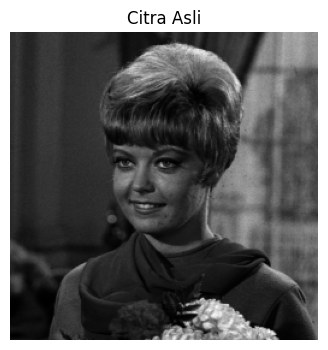

In [5]:
# Load citra grayscale
img = cv.imread('/content/drive/MyDrive/PCVK/female.tiff', cv.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError("❌ Gambar tidak ditemukan.")

plt.figure(figsize=(4,4))
plt.imshow(img, cmap='gray')
plt.title("Citra Asli")
plt.axis('off')
plt.show()


In [6]:
# Kernel dasar
average_filter = np.ones((3,3), np.float32) / 9

low_pass_filter = np.array([
    [1, 1, 1],
    [1, 4, 1],
    [1, 1, 1]
], np.float32) / 12

high_pass_filter = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], np.float32)

sharpen_filter = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
], np.float32)

emboss_filter = np.array([
    [-2, -1, 0],
    [-1,  1, 1],
    [0,   1, 2]
], np.float32)

prewitt_filter = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], np.float32)

sobel_filter = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
], np.float32)


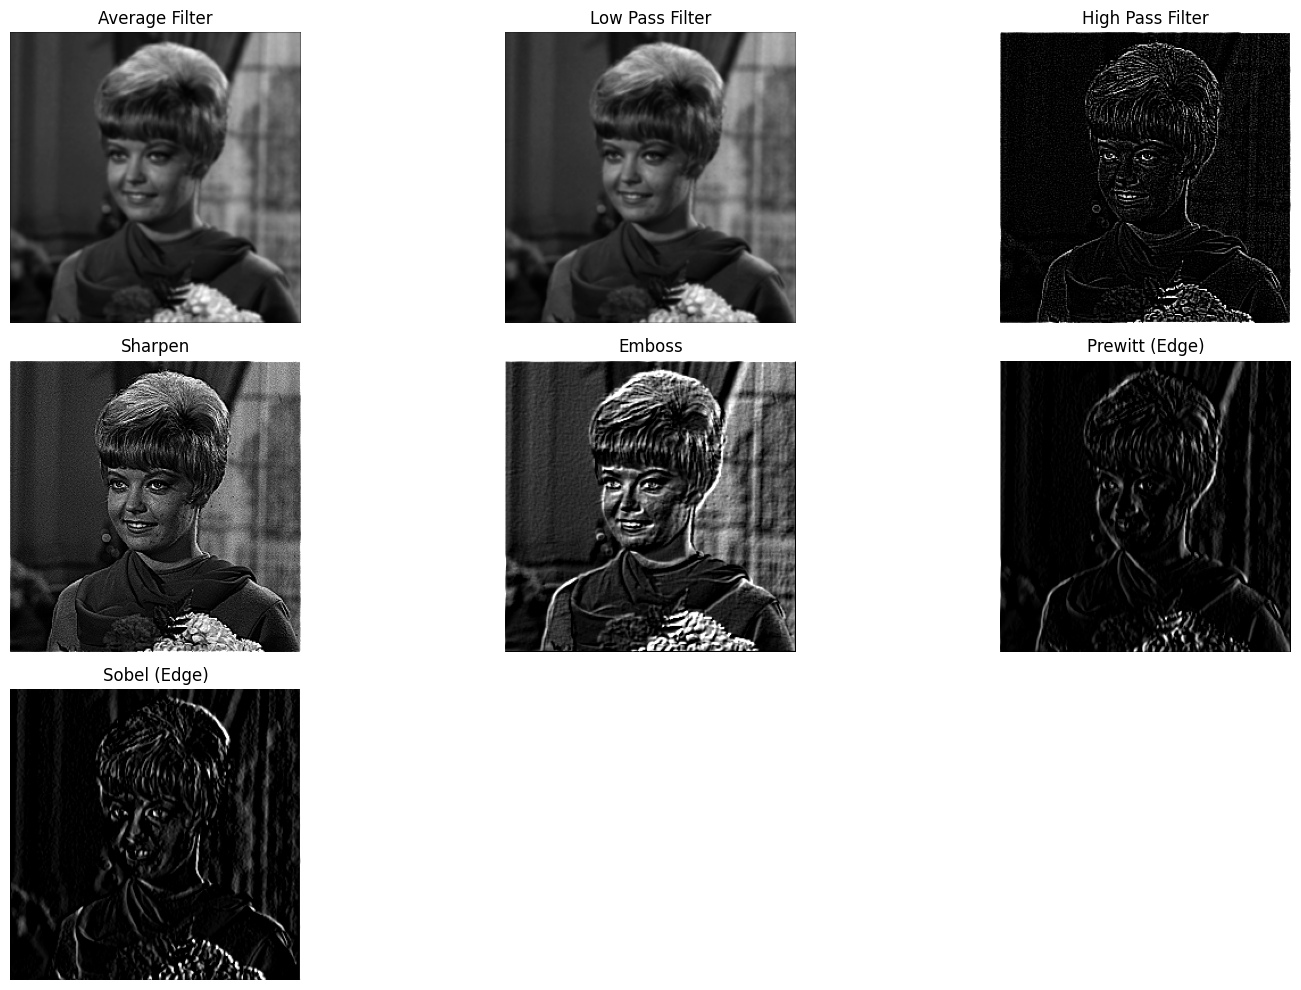

In [7]:
filters = {
    'Average Filter': average_filter,
    'Low Pass Filter': low_pass_filter,
    'High Pass Filter': high_pass_filter,
    'Sharpen': sharpen_filter,
    'Emboss': emboss_filter,
    'Prewitt (Edge)': prewitt_filter,
    'Sobel (Edge)': sobel_filter
}

plt.figure(figsize=(15,10))
for i, (name, kernel) in enumerate(filters.items()):
    result = convolution(img, kernel)
    plt.subplot(3,3,i+1)
    plt.imshow(result, cmap='gray')
    plt.title(name)
    plt.axis('off')
plt.tight_layout()
plt.show()


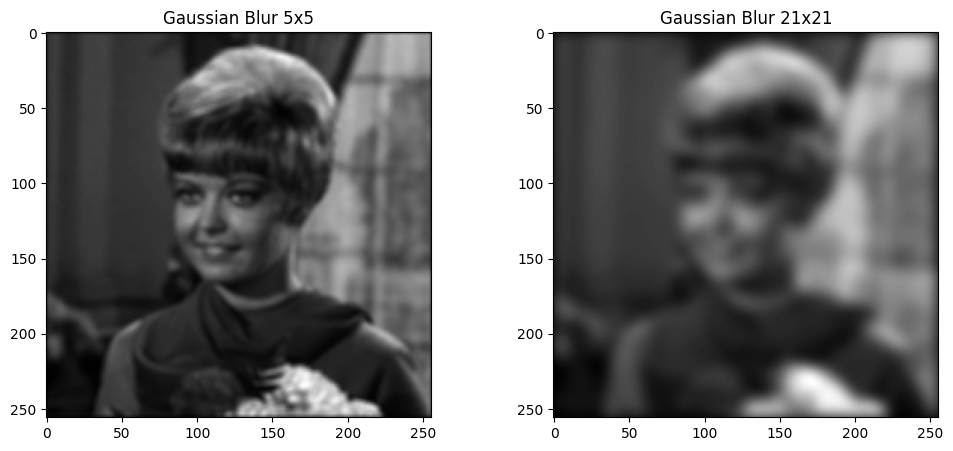

In [8]:
import math

def gaussian_kernel(size):
    sigma = math.sqrt(size)
    gk = cv.getGaussianKernel(size, sigma)
    return gk @ gk.T

gaussian5 = gaussian_kernel(5)
gaussian21 = gaussian_kernel(21)

blur5 = convolution(img, gaussian5)
blur21 = convolution(img, gaussian21)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(blur5, cmap='gray')
plt.title("Gaussian Blur 5x5")

plt.subplot(1,2,2)
plt.imshow(blur21, cmap='gray')
plt.title("Gaussian Blur 21x21")
plt.show()


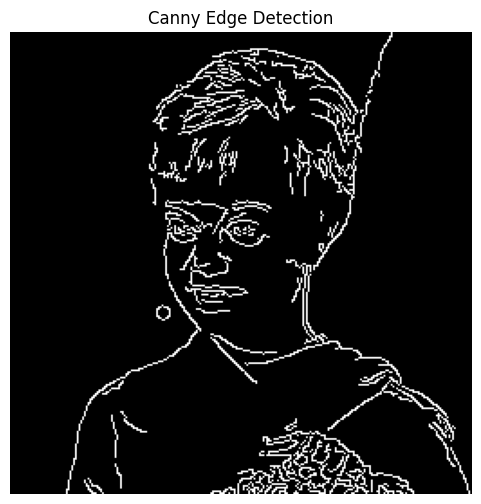

In [9]:
edges = cv.Canny(img, 100, 200)

plt.figure(figsize=(6,6))
plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis('off')
plt.show()


Dari semua percobaan di atas, dapat disimpulkan:

Filter spasial bekerja dengan melakukan konvolusi kernel terhadap piksel citra untuk menghasilkan efek tertentu.

Low-pass filters (Average, Gaussian) melembutkan citra dengan menekan frekuensi tinggi (noise).

High-pass filters (Sharpen, Edge Detection) memperjelas detail dan menonjolkan tepi.

Emboss menghasilkan efek timbul dengan menekankan perbedaan arah cahaya.

Canny memberikan deteksi tepi paling halus dan stabil.

Perubahan kernel secara langsung memengaruhi bentuk dan arah detail yang ditonjolkan pada citra hasil.